In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',50)

In [2]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
import lightgbm as lgb
import xgboost as xgb
import shap
import joblib

In [4]:
df = pd.read_csv('/Users/alfiyaansari/Desktop/Project/apr20_price_33_col.csv')
df.head()

,Unnamed: 0,obj_regio1,obj_heatingType,obj_cId,obj_newlyConst,obj_pricetrend,obj_yearConstructed,obj_pricetrendbuy,obj_firingTypes,obj_ExclusiveExpose,geo_bln,obj_cellar,obj_houseNumber,obj_livingSpace,geo_krs,obj_zipCode,obj_condition,obj_street,obj_streetPlain,geo_plz,obj_noRooms,geo_land,ga_cd_via,obj_immotype,obj_telekomInternetProductAvailable,obj_barrierFree,obj_regio3,obj_objectnumber,obj_livingSpaceRange,obj_regio2,obj_telekomTvOffer,obj_telekomUploadSpeed,obj_telekomDownloadSpeed,obj_purchasePrice
0,0,Sachsen,heat_pump,544685.0,y,9.12,2021.0,9.12,no_information,True,Sachsen,n,no_information,152.00,Leipzig_Kreis,4571.0,first_time_use,no_information,no_information,4571.0,4.0,Deutschland,schaufenster,haus_kauf,False,n,Espenhain,W16138,4.0,Leipzig_Kreis,NaN,NaN,NaN,445900.0
1,1,Berlin,central_heating,5240003.0,n,11.35,1934.0,11.35,gas,False,Berlin,y,0,65.00,Berlin,12357.0,refurbished,Windenweg,Windenweg,12357.0,2.0,Deutschland,standard,haus_kauf,True,n,Rudow_Neukölln,DHH 16042020-004,1.0,Berlin,ONE_YEAR_FREE,40 MBit/s,100 MBit/s,545000.0
2,2,Baden_Württemberg,stove_heating,954015.0,n,5.59,1920.0,5.59,wood,False,Baden_Württemberg,y,no_information,159.00,Rhein_Neckar_Kreis,69434.0,no_information,no_information,no_information,69434.0,6.5,Deutschland,standard,haus_kauf,False,n,Heddesbach,030420201,4.0,Rhein_Neckar_Kreis,NaN,NaN,NaN,195000.0
3,3,Schleswig_Holstein,NaN,134629.0,n,9.62,1972.0,9.62,gas,True,Schleswig_Holstein,y,no_information,104.78,Segeberg_Kreis,24558.0,no_information,no_information,no_information,24558.0,4.0,Deutschland,standard,haus_kauf,True,n,Henstedt_Ulzburg,V5062a,2.0,Segeberg_Kreis,ONE_YEAR_FREE,40 MBit/s,100 MBit/s,309000.0
4,4,Niedersachsen,NaN,18406763.0,n,11.40,NaN,11.40,no_information,True,Niedersachsen,n,no_information,140.00,Emsland_Kreis,49774.0,no_information,no_information,no_information,49774.0,5.0,Deutschland,standard,haus_kauf,False,n,Lähden,12385-306-17/20 EVOLUTION 136,3.0,Emsland_Kreis,NaN,NaN,NaN,267777.0


In [7]:
column_rename_map = {
    'obj_regio1': 'federal_state','obj_regio2': 'district',
    'obj_regio3': 'municipality','geo_land': 'country','geo_plz': 'postal_code','obj_zipCode': 'zip_code',
    'obj_immotype': 'property_type','obj_condition': 'property_condition','obj_yearConstructed': 'year_built',
    'obj_newlyConst': 'is_new_construction','obj_livingSpace': 'living_area_sqm','obj_livingSpaceRange': 'living_area_range',
    'obj_noRooms': 'num_rooms','obj_cellar': 'has_cellar','obj_barrierFree': 'is_barrier_free',
    'obj_heatingType': 'heating_type','obj_firingTypes': 'firing_type','obj_pricetrend': 'price_trend_rent',
    'obj_pricetrendbuy': 'price_trend_buy','obj_telekomDownloadSpeed': 'internet_download_mbps',
    'obj_telekomUploadSpeed': 'internet_upload_mbps','obj_telekomTvOffer': 'has_tv_offer',
    'obj_telekomInternetProductAvailable': 'has_internet','obj_ExclusiveExpose': 'exclusive_listing','obj_purchasePrice': 'purchase_price'
}

In [8]:
df = df.rename(columns=column_rename_map)

In [9]:
df = df.drop(columns=['Unnamed: 0', 'obj_objectnumber','obj_cId','ga_cd_via','obj_zipCode','obj_street','obj_livingSpaceRange',
                                            'country','postal_code'], errors='ignore')

In [10]:
df = df[["federal_state","district","municipality","zip_code","property_condition",
    "year_built","is_new_construction","living_area_sqm","num_rooms","has_cellar","is_barrier_free",
    "heating_type","firing_type","price_trend_buy","internet_download_mbps","has_tv_offer",
    "has_internet","exclusive_listing","purchase_price"]]

In [11]:
df.head()

,federal_state,district,municipality,zip_code,property_condition,year_built,is_new_construction,living_area_sqm,num_rooms,has_cellar,is_barrier_free,heating_type,firing_type,price_trend_buy,internet_download_mbps,has_tv_offer,has_internet,exclusive_listing,purchase_price
0,Sachsen,Leipzig_Kreis,Espenhain,4571.0,first_time_use,2021.0,y,152.00,4.0,n,n,heat_pump,no_information,9.12,NaN,NaN,False,True,445900.0
1,Berlin,Berlin,Rudow_Neukölln,12357.0,refurbished,1934.0,n,65.00,2.0,y,n,central_heating,gas,11.35,100 MBit/s,ONE_YEAR_FREE,True,False,545000.0
2,Baden_Württemberg,Rhein_Neckar_Kreis,Heddesbach,69434.0,no_information,1920.0,n,159.00,6.5,y,n,stove_heating,wood,5.59,NaN,NaN,False,False,195000.0
3,Schleswig_Holstein,Segeberg_Kreis,Henstedt_Ulzburg,24558.0,no_information,1972.0,n,104.78,4.0,y,n,NaN,gas,9.62,100 MBit/s,ONE_YEAR_FREE,True,True,309000.0
4,Niedersachsen,Emsland_Kreis,Lähden,49774.0,no_information,NaN,n,140.00,5.0,n,n,NaN,no_information,11.40,NaN,NaN,False,True,267777.0


In [12]:
print('Number of Rows :', df.shape[0])
print('Number of Columns :', df.shape[1])

Number of Rows : 46262
Number of Columns : 19


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46262 entries, 0 to 46261
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   federal_state           46262 non-null  object 
 1   district                46262 non-null  object 
 2   municipality            46262 non-null  object 
 3   zip_code                46262 non-null  float64
 4   property_condition      46262 non-null  object 
 5   year_built              40276 non-null  float64
 6   is_new_construction     46262 non-null  object 
 7   living_area_sqm         46262 non-null  float64
 8   num_rooms               46262 non-null  float64
 9   has_cellar              46262 non-null  object 
 10  is_barrier_free         46262 non-null  object 
 11  heating_type            39004 non-null  object 
 12  firing_type             43063 non-null  object 
 13  price_trend_buy         38208 non-null  float64
 14  internet_download_mbps  37524 non-null

In [14]:
df.describe()

,zip_code,year_built,living_area_sqm,num_rooms,price_trend_buy,purchase_price
count,46262.000000,40276.000000,46262.000000,46262.000000,38208.000000,4.626200e+04
mean,47663.892223,1963.727406,211.710340,7.088669,7.483964,5.408054e+05
std,26612.305104,59.398147,329.564259,6.248201,3.038347,1.213126e+06
min,1057.000000,1058.000000,0.000000,1.000000,-9.310000,0.000000e+00
25%,25560.000000,1936.000000,126.000000,4.500000,5.670000,2.400000e+05
50%,47546.000000,1973.000000,160.040000,6.000000,7.470000,3.800000e+05
75%,67823.000000,2002.000000,233.000000,8.000000,9.370000,5.980000e+05
max,99998.000000,5410.000000,38500.000000,400.000000,22.270000,1.600000e+08


In [15]:
df.isnull().sum()

federal_state                0
district                     0
municipality                 0
zip_code                     0
property_condition           0
year_built                5986
is_new_construction          0
living_area_sqm              0
num_rooms                    0
has_cellar                   0
is_barrier_free              0
heating_type              7258
firing_type               3199
price_trend_buy           8054
internet_download_mbps    8738
has_tv_offer              7936
has_internet              3160
exclusive_listing           10
purchase_price               0
dtype: int64

In [18]:
cols = ['num_rooms','living_area_sqm','zip_code','num_rooms','purchase_price']

In [19]:
for col in cols:
    df[col] = df[col].astype(int)

In [20]:
df['internet_download_mbps'] = df['internet_download_mbps'].str.replace('MBit/s','',regex=False).astype(float)

In [21]:
df['year_built'].isnull().sum()

5986

In [22]:
df['year_built'] = pd.to_numeric(df['year_built'], errors='coerce').astype('Int64')

In [23]:
max_year = 2020
df['year_built'] = df['year_built'].clip(upper=max_year)

In [24]:
df.head()

,federal_state,district,municipality,zip_code,property_condition,year_built,is_new_construction,living_area_sqm,num_rooms,has_cellar,is_barrier_free,heating_type,firing_type,price_trend_buy,internet_download_mbps,has_tv_offer,has_internet,exclusive_listing,purchase_price
0,Sachsen,Leipzig_Kreis,Espenhain,4571,first_time_use,2020,y,152,4,n,n,heat_pump,no_information,9.12,NaN,NaN,False,True,445900
1,Berlin,Berlin,Rudow_Neukölln,12357,refurbished,1934,n,65,2,y,n,central_heating,gas,11.35,100.0,ONE_YEAR_FREE,True,False,545000
2,Baden_Württemberg,Rhein_Neckar_Kreis,Heddesbach,69434,no_information,1920,n,159,6,y,n,stove_heating,wood,5.59,NaN,NaN,False,False,195000
3,Schleswig_Holstein,Segeberg_Kreis,Henstedt_Ulzburg,24558,no_information,1972,n,104,4,y,n,NaN,gas,9.62,100.0,ONE_YEAR_FREE,True,True,309000
4,Niedersachsen,Emsland_Kreis,Lähden,49774,no_information,<NA>,n,140,5,n,n,NaN,no_information,11.40,NaN,NaN,False,True,267777


In [25]:
df['log_purchase_price'] = np.log1p(df['purchase_price'])

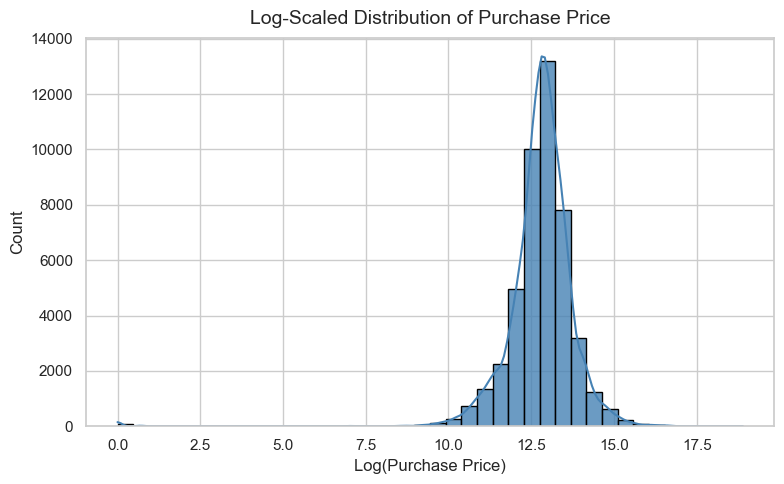

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df,x='log_purchase_price',bins=40,kde=True,color='steelblue',edgecolor='black', alpha=0.8)
plt.title('Log-Scaled Distribution of Purchase Price', fontsize=14, pad=10)
plt.xlabel('Log(Purchase Price)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

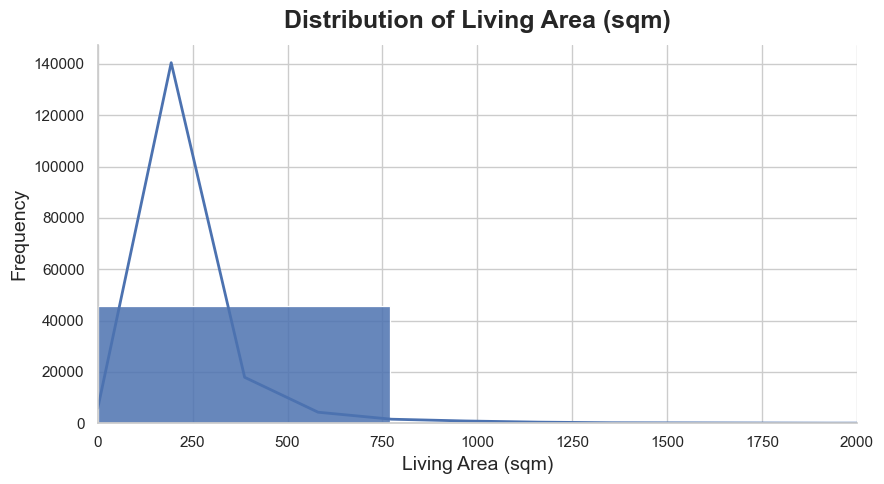

In [33]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df,x='living_area_sqm',bins=50,kde=True,color='#4C72B0',edgecolor='white',alpha=0.85,line_kws={'linewidth': 2})
plt.title('Distribution of Living Area (sqm)', fontsize=18, weight='bold', pad=12)
plt.xlabel('Living Area (sqm)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xlim(0, 2000)
sns.despine()
plt.tight_layout()
plt.show()

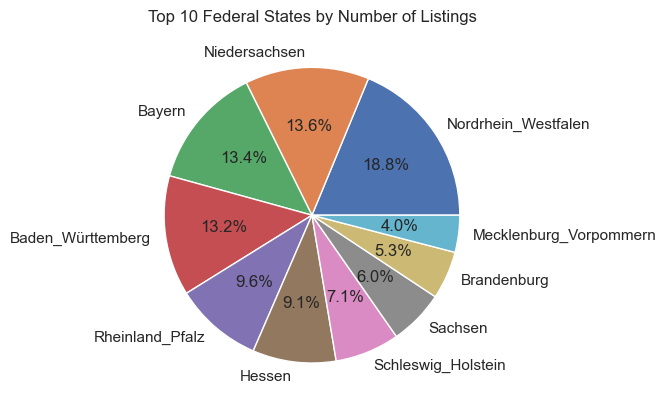

In [28]:
top_federal_states = df['federal_state'].value_counts().head(10)
plt.pie(top_federal_states, labels=top_federal_states.index, autopct='%1.1f%%')
plt.title('Top 10 Federal States by Number of Listings')
plt.show()

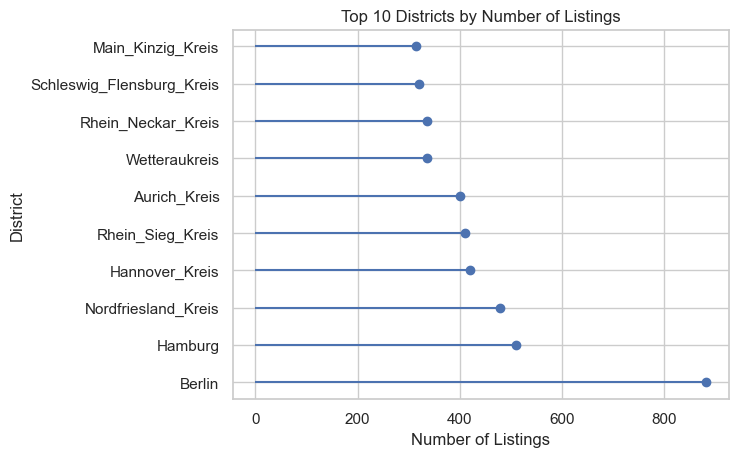

In [34]:
top_districts = df['district'].value_counts().head(10)
plt.hlines(y=top_districts.index, xmin=0, xmax=top_districts.values)
plt.plot(top_districts.values, top_districts.index, "o")
plt.xlabel("Number of Listings")
plt.ylabel("District")
plt.title("Top 10 Districts by Number of Listings")
plt.show()

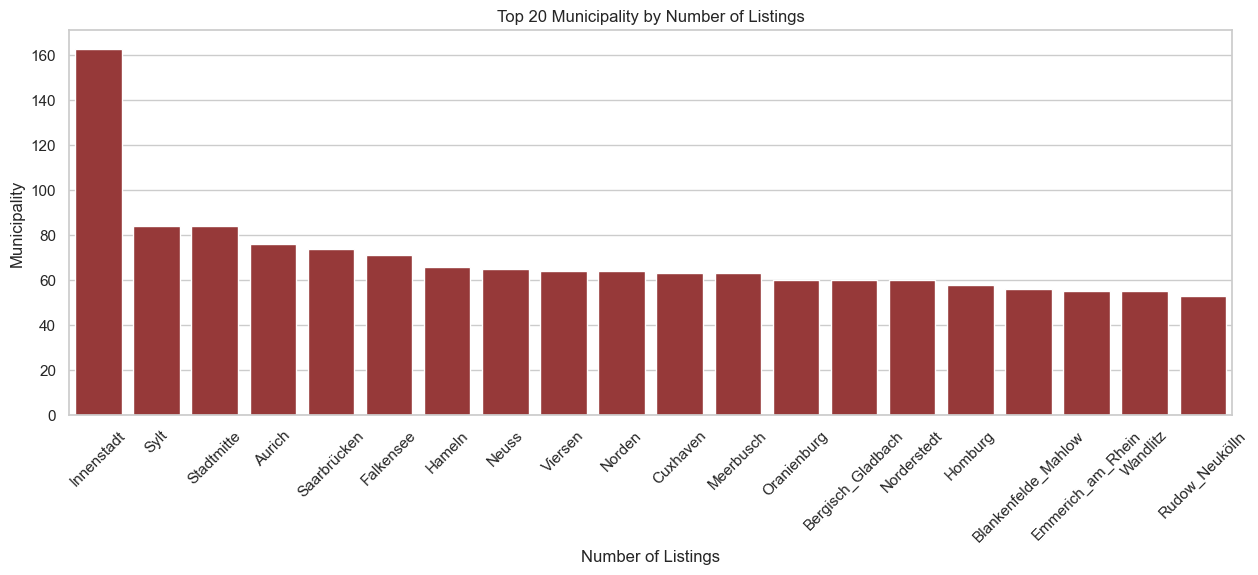

In [35]:
top_municipality = df['municipality'].value_counts().head(20).reset_index()
top_municipality.columns = ['municipality','count']
plt.figure(figsize=(15,5))
sns.barplot(data=top_municipality, y='count', x='municipality', color='brown')
plt.title('Top 20 Municipality by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Municipality')
plt.xticks(rotation=45)
plt.show()

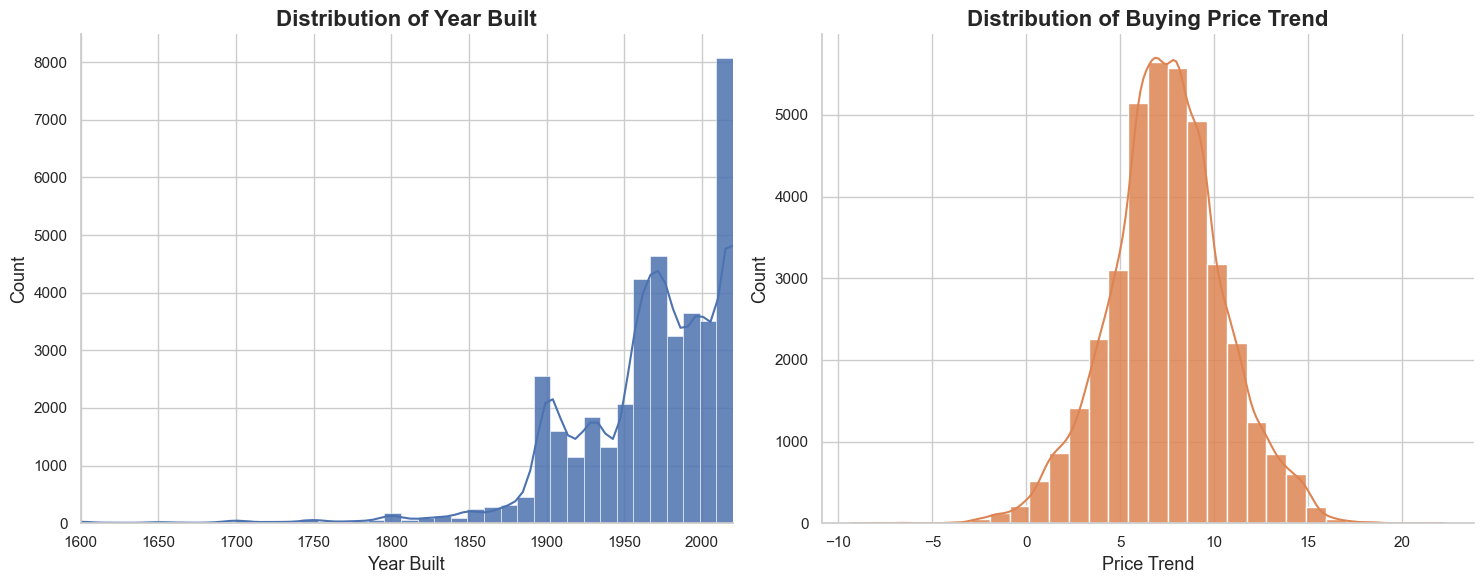

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

sns.histplot(data=df,x='year_built',bins=90,kde=True,color='#4C72B0',edgecolor='white',alpha=0.85,ax=axes[0])
axes[0].set_title('Distribution of Year Built', fontsize=16, weight='bold')
axes[0].set_xlabel('Year Built', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_xlim(1600, 2020)

sns.histplot(data=df,x='price_trend_buy',bins=30,kde=True,color='#DD8452',edgecolor='white',alpha=0.85,ax=axes[1])
axes[1].set_title('Distribution of Buying Price Trend', fontsize=16, weight='bold')
axes[1].set_xlabel('Price Trend', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

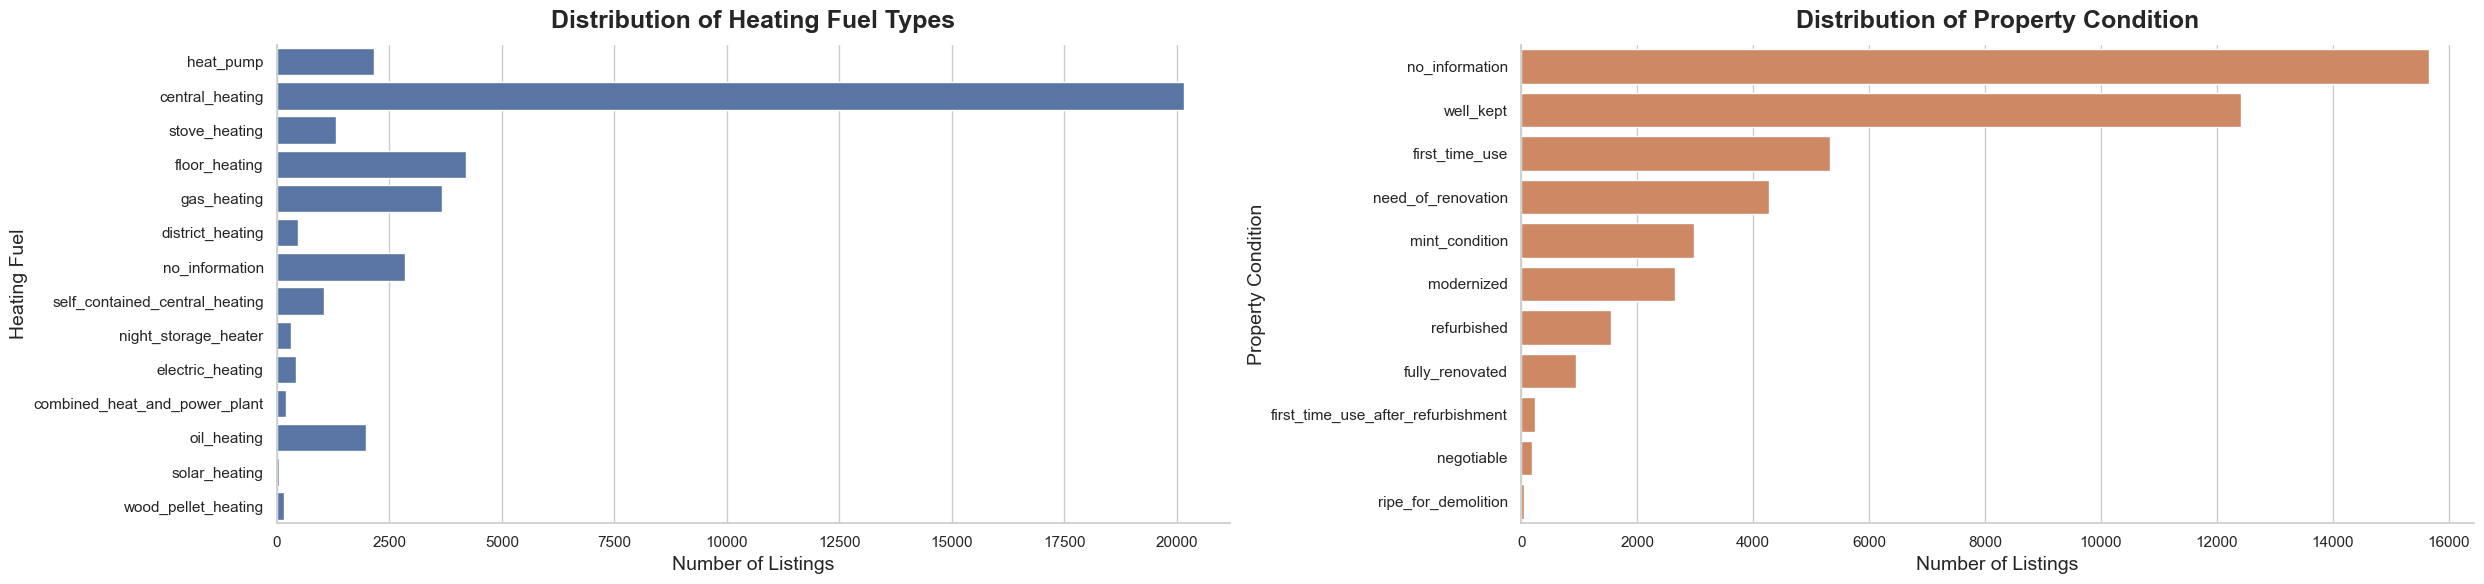

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(25, 6), sharex=False)
sns.countplot(data=df,y='heating_type',color='#4C72B0',edgecolor='white',ax=axes[0])
axes[0].set_title('Distribution of Heating Fuel Types', fontsize=18, weight='bold', pad=12)
axes[0].set_xlabel('Number of Listings', fontsize=14)
axes[0].set_ylabel('Heating Fuel', fontsize=14)

sns.countplot(data=df,y='property_condition',order=df['property_condition'].value_counts().index,color='#DD8452',edgecolor='white',
              ax=axes[1])
axes[1].set_title('Distribution of Property Condition', fontsize=18, weight='bold', pad=12)
axes[1].set_xlabel('Number of Listings', fontsize=14)
axes[1].set_ylabel('Property Condition', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

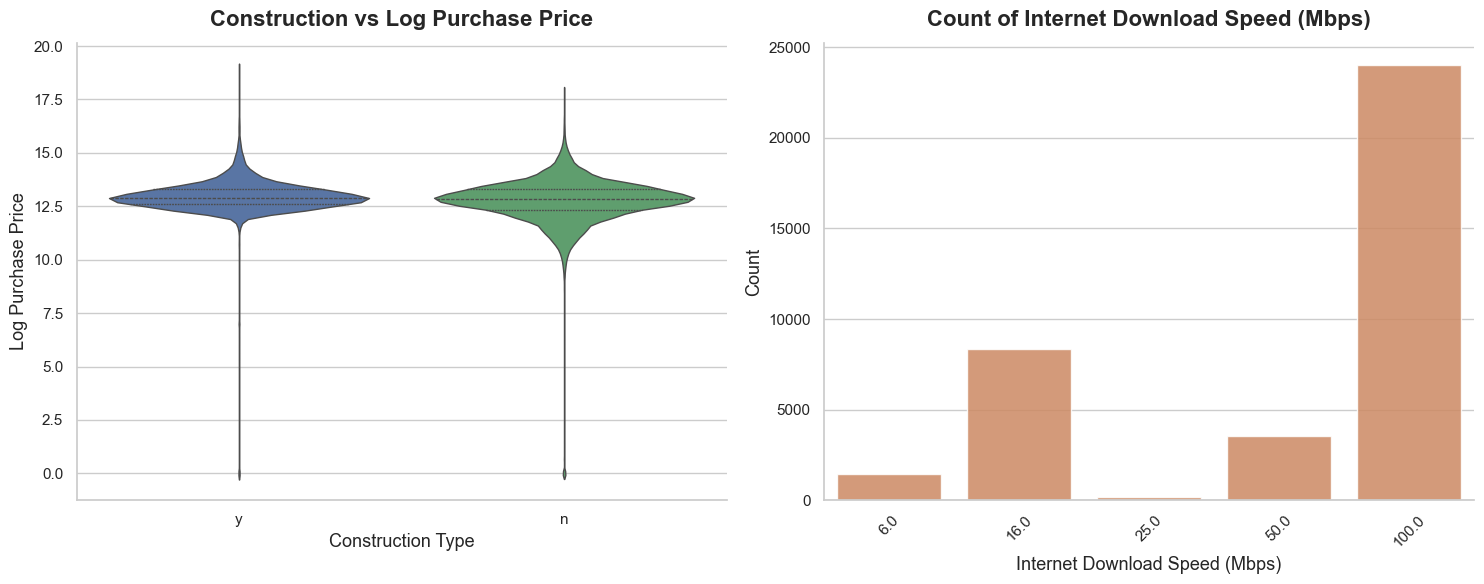

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(data=df,x='is_new_construction',y='log_purchase_price',
               palette=['#4C72B0', '#55A868'],ax=axes[0],inner='quartile',linewidth=1.)

axes[0].set_title('Construction vs Log Purchase Price', fontsize=16, weight='bold', pad=12)
axes[0].set_xlabel('Construction Type', fontsize=13)
axes[0].set_ylabel('Log Purchase Price', fontsize=13)


sns.countplot(data=df,x='internet_download_mbps',color='#DD8452',edgecolor='white',alpha=0.85,ax=axes[1])
axes[1].set_title('Count of Internet Download Speed (Mbps)', fontsize=16, weight='bold', pad=12)
axes[1].set_xlabel('Internet Download Speed (Mbps)', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

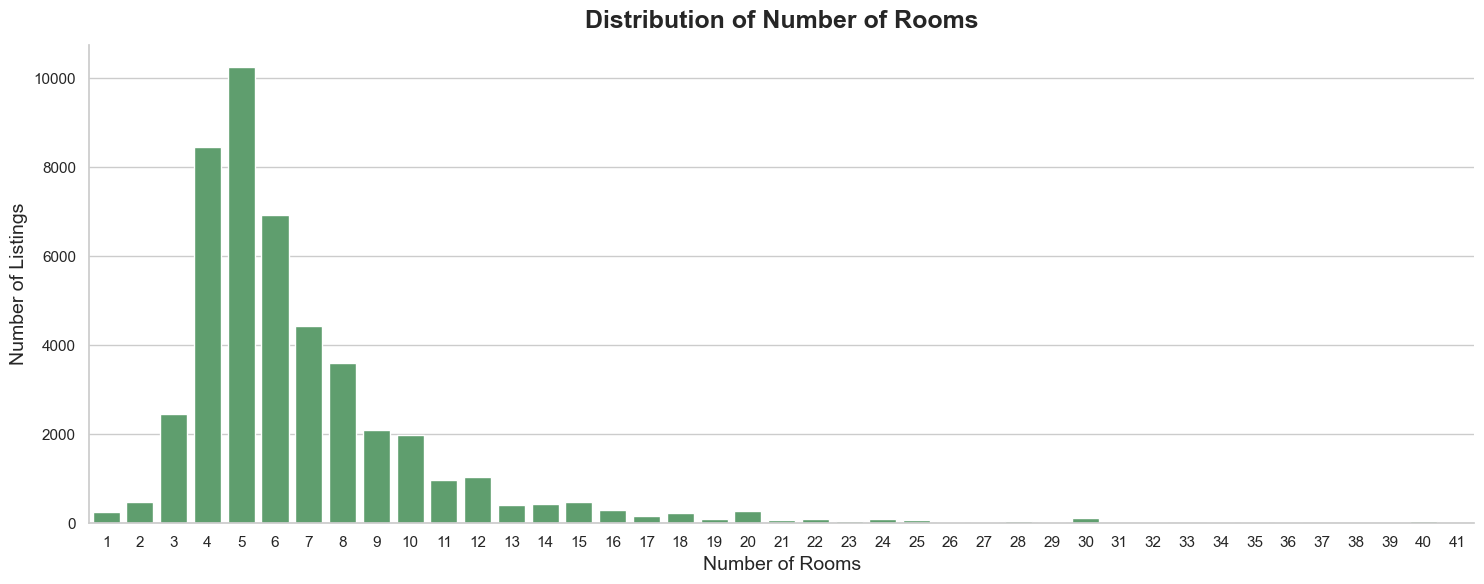

In [42]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df,x='num_rooms',color='#55A868',edgecolor='white')

plt.title('Distribution of Number of Rooms', fontsize=18, weight='bold', pad=12)
plt.xlabel('Number of Rooms', fontsize=14)
plt.ylabel('Number of Listings', fontsize=14)

plt.xlim(-0.5, 40.5)

sns.despine()
plt.tight_layout()
plt.show()

In [45]:
num_cols = df.select_dtypes(exclude=['object'])

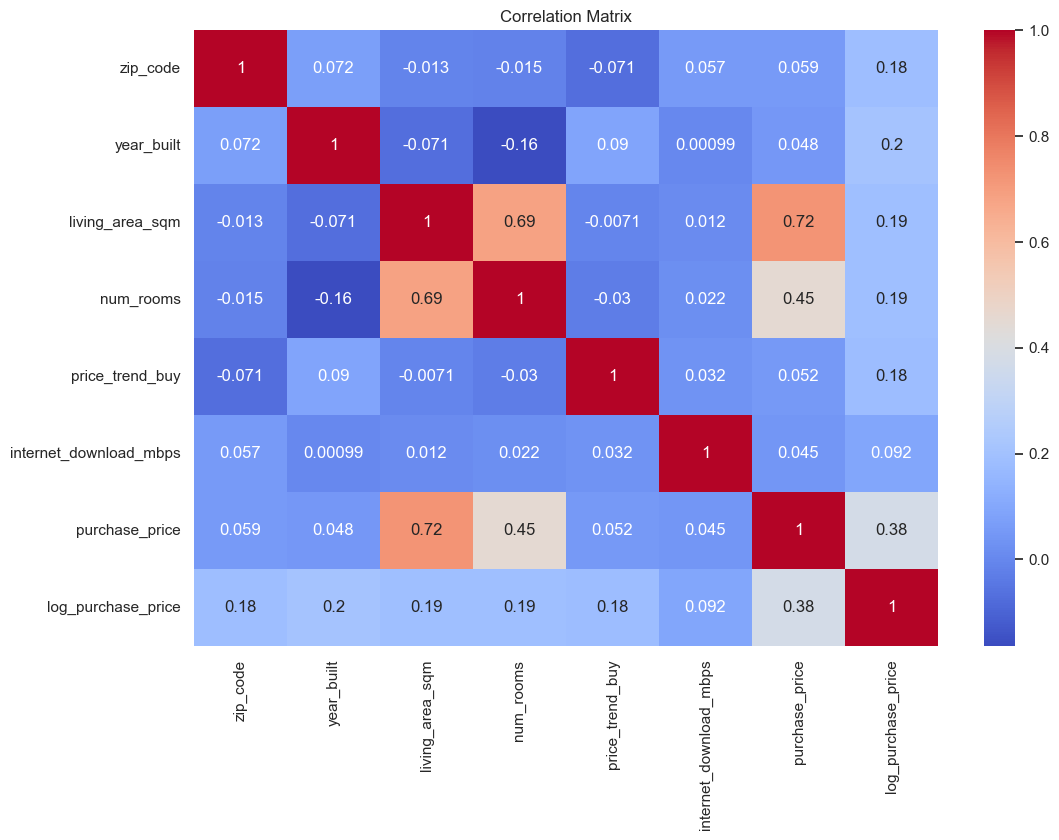

In [46]:
plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

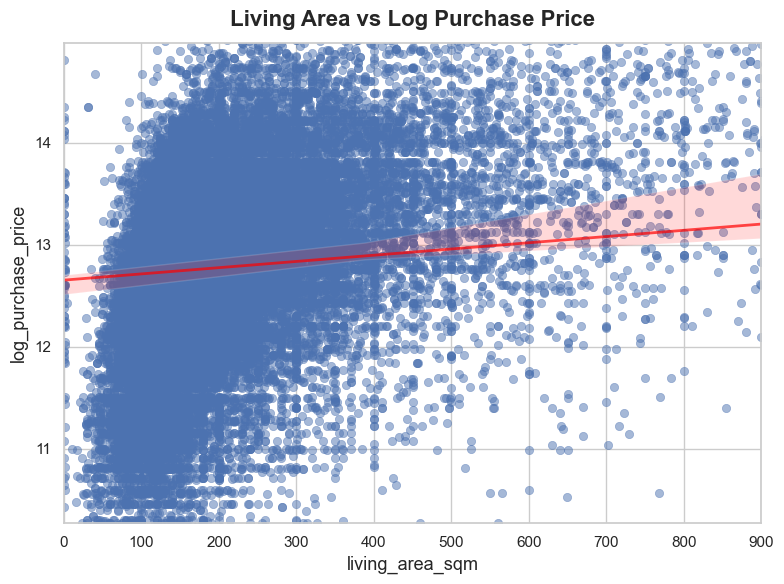

In [48]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df,x='living_area_sqm',y='log_purchase_price',alpha=0.5,color='#4C72B0',edgecolor=None)
plt.xlabel("Living Area (sqm)", fontsize=13)
plt.ylabel("Log Purchase Price", fontsize=13)
plt.title("Living Area vs Log Purchase Price", fontsize=16, weight='bold', pad=12)

sns.regplot(data=df,x='living_area_sqm',y='log_purchase_price',scatter=False,ax=plt.gca(),
            color='red',line_kws={'linewidth':2, 'alpha':0.7})
plt.xlim(0, df['living_area_sqm'].quantile(0.99)) 
plt.ylim(df['log_purchase_price'].quantile(0.01), df['log_purchase_price'].quantile(0.99))
plt.tight_layout()
plt.show()

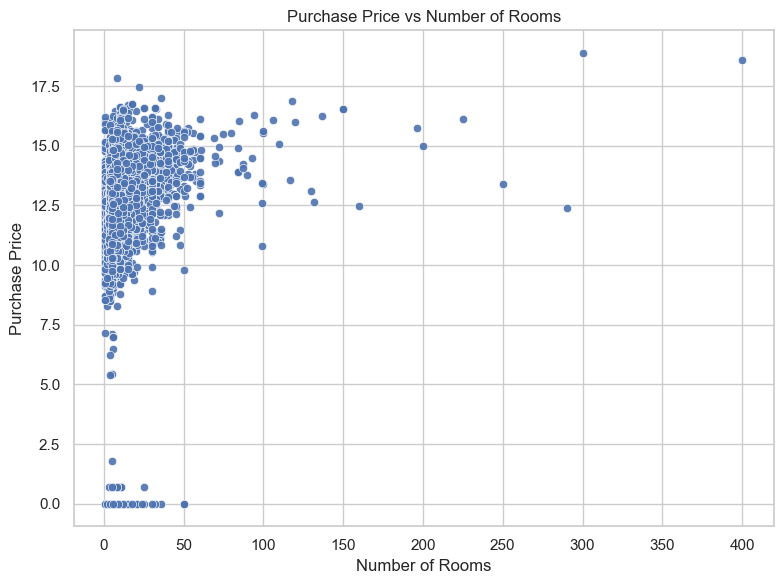

In [49]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='num_rooms',y='log_purchase_price',alpha=0.9)
plt.title("Purchase Price vs Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Purchase Price")
plt.tight_layout()
plt.show()

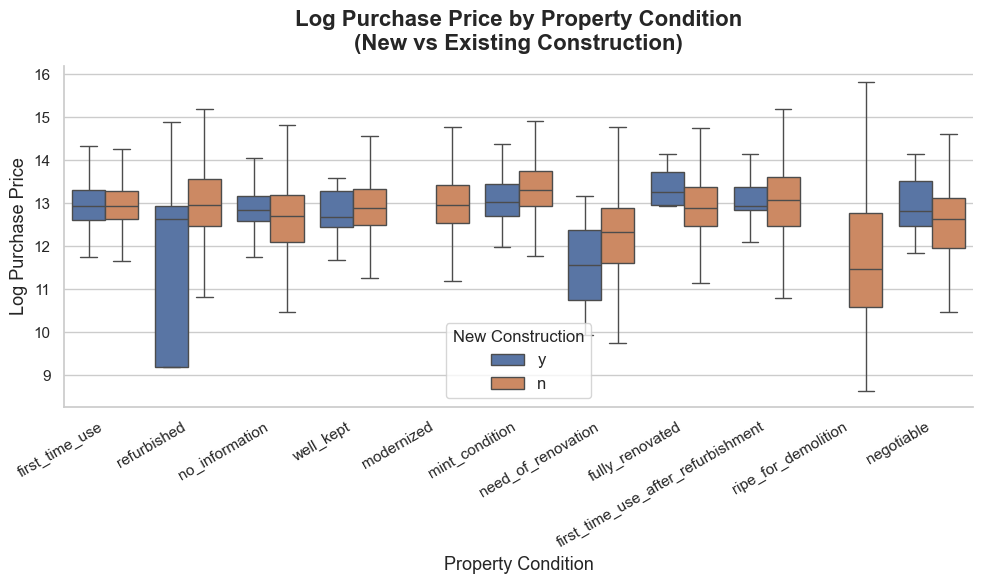

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x='property_condition',y='log_purchase_price',hue='is_new_construction',showfliers=False)
plt.title("Log Purchase Price by Property Condition\n(New vs Existing Construction)",fontsize=16,weight='bold',pad=12)
plt.xlabel("Property Condition", fontsize=13)
plt.ylabel("Log Purchase Price", fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.legend(title="New Construction", fontsize=12, title_fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

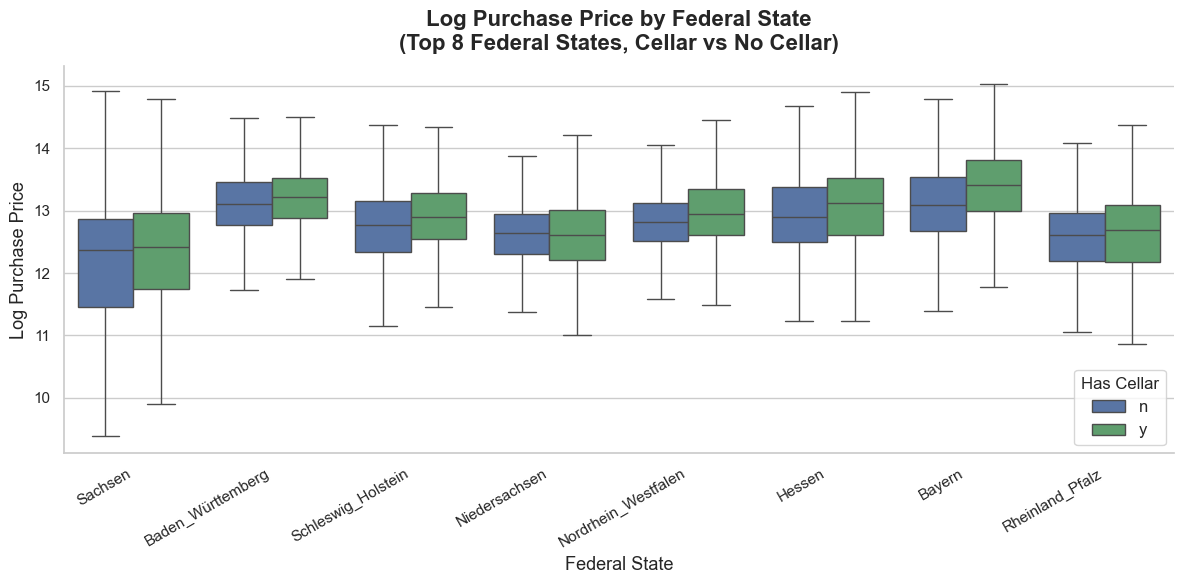

In [56]:
top_federal_state = df['federal_state'].value_counts().head(8).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['federal_state'].isin(top_federal_state)],x='federal_state',y='log_purchase_price',hue='has_cellar',
            showfliers=False,palette=['#4C72B0', '#55A868'])
plt.title("Log Purchase Price by Federal State\n(Top 8 Federal States, Cellar vs No Cellar)",
          fontsize=16,weight='bold',pad=12)
plt.xlabel("Federal State", fontsize=13)
plt.ylabel("Log Purchase Price", fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.legend(title="Has Cellar", fontsize=12, title_fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

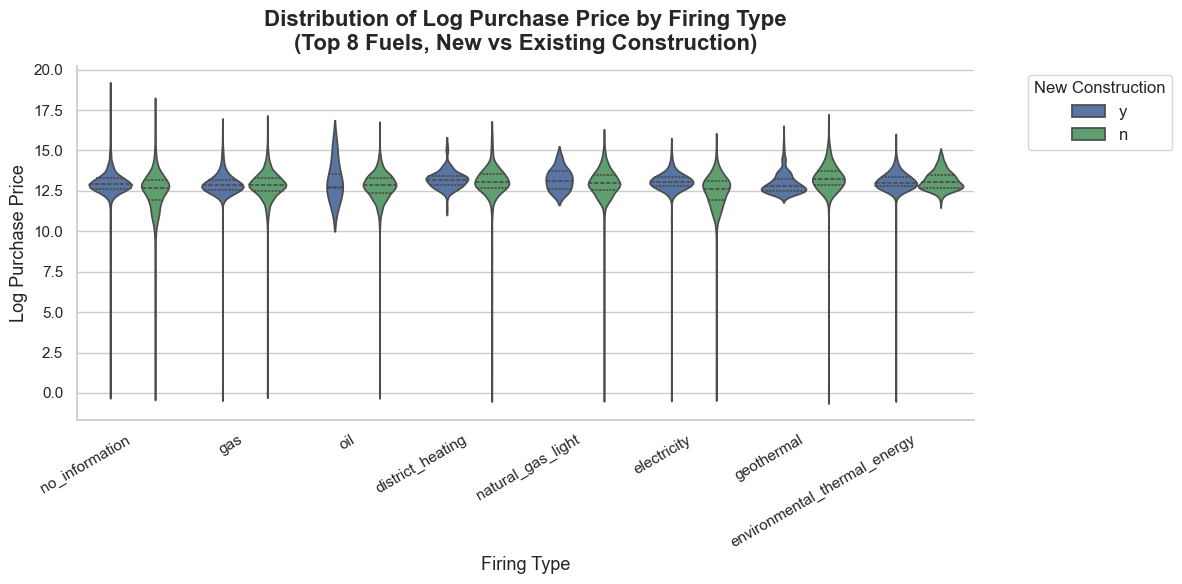

In [58]:
top_fuels = df['firing_type'].value_counts().head(8).index
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[df['firing_type'].isin(top_fuels)],x='firing_type',y='log_purchase_price',hue='is_new_construction',
               palette=['#4C72B0', '#55A868'],inner='quartile',split=False)
plt.title("Distribution of Log Purchase Price by Firing Type\n(Top 8 Fuels, New vs Existing Construction)",
          fontsize=16,weight='bold',pad=12)
plt.xlabel("Firing Type", fontsize=13)
plt.ylabel("Log Purchase Price", fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.legend(title="New Construction", fontsize=12, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

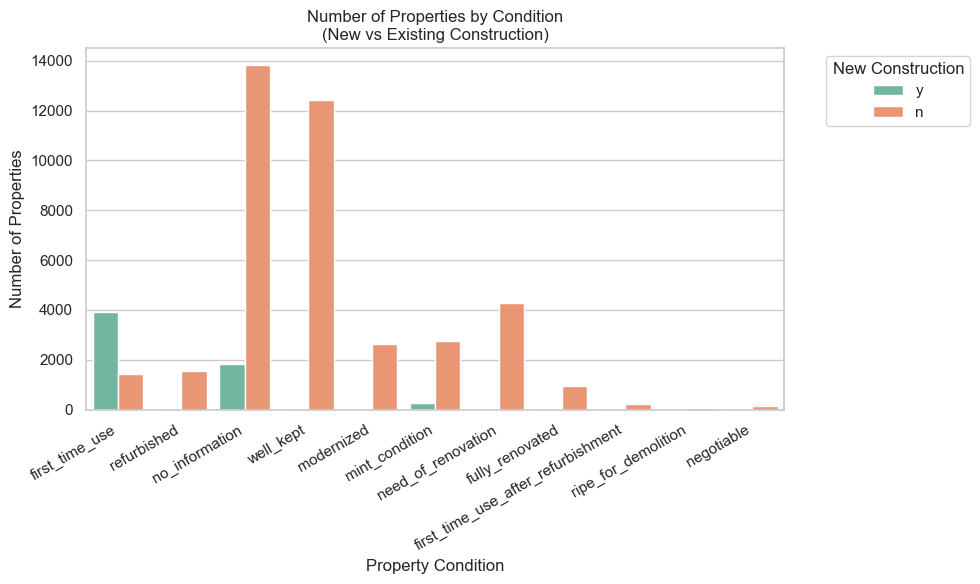

In [59]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df,x='property_condition',hue='is_new_construction',palette="Set2")
plt.title("Number of Properties by Condition\n(New vs Existing Construction)")
plt.xlabel("Property Condition")
plt.ylabel("Number of Properties")
plt.xticks(rotation=30, ha='right')
plt.legend(title="New Construction", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

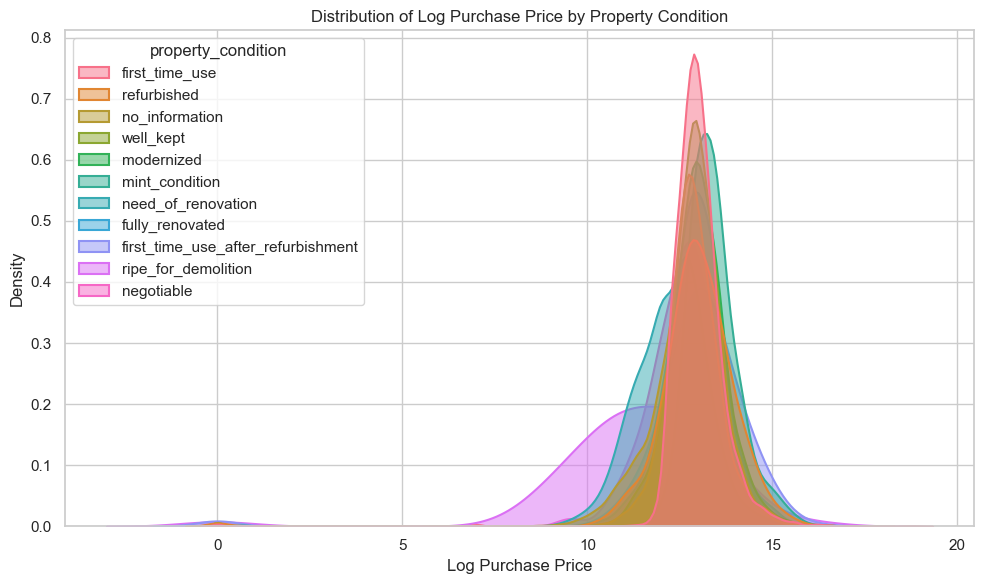

In [60]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df,x='log_purchase_price',hue='property_condition',common_norm=False,alpha=0.5,linewidth=1.5,fill=True)
plt.title("Distribution of Log Purchase Price by Property Condition")
plt.xlabel("Log Purchase Price")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

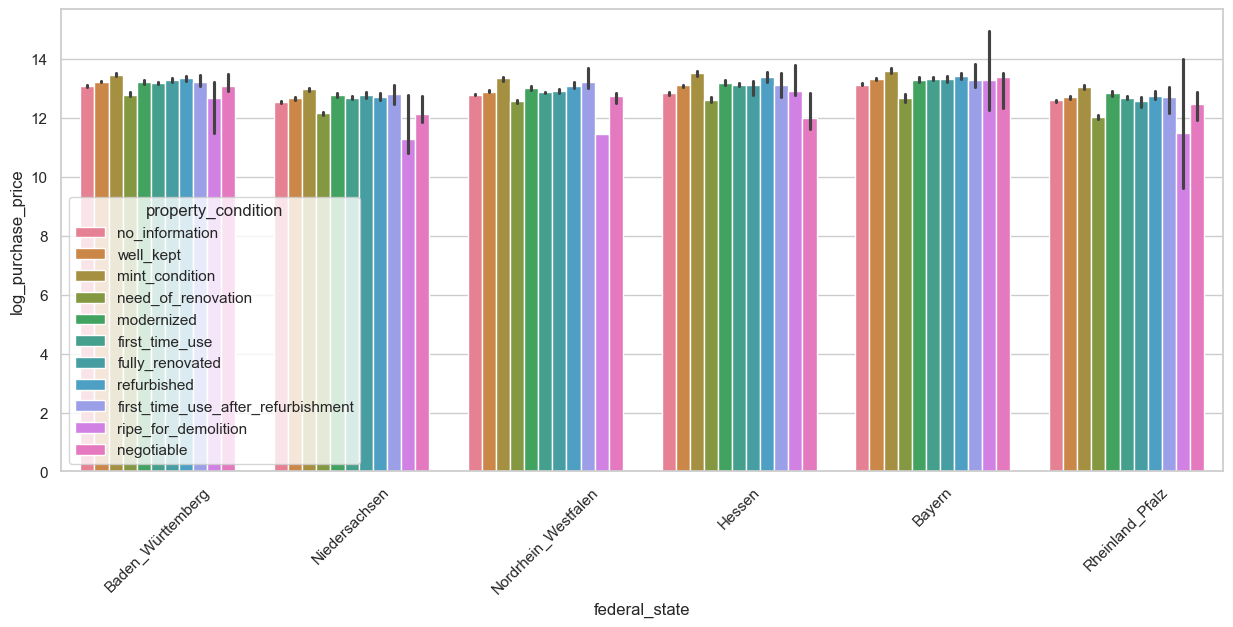

In [61]:
plt.figure(figsize=(15,6))
top_federal_state = df['federal_state'].value_counts().head(6).index
sns.barplot(data=df[df['federal_state'].isin(top_federal_state)],x='federal_state',
            y='log_purchase_price',hue='property_condition',estimator='median')
plt.xticks(rotation=45)
plt.show()

In [62]:
df.drop('log_purchase_price',axis=1,inplace=True)

In [63]:
x = df.drop("purchase_price", axis=1)
y = df['purchase_price']

In [64]:
categorical_cols = x.select_dtypes(include="object").columns.tolist()
numerical_cols = x.select_dtypes(include=['float64','int64']).columns.tolist()

In [65]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [66]:
cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
    
])

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ]
)

In [68]:
def xgb_model():
    return xgb.XGBRegressor(objective="reg:squarederror",n_estimators=600,
                           learning_rate = 0.05, max_depth=8, subsample=0.8, colsample_bytree=0.8,
                           random_state=42, n_jobs=-1)

In [69]:
def lgbm_quantile(alpha):
    return lgb.LGBMRegressor(
        objective = "quantile", alpha=alpha, n_estimators=600,learning_rate=0.05,
        max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42,n_jobs=-1
    )

In [70]:
def pinball_loss(y_true, y_pred, alpha):
    error = y_true - y_pred
    return np.mean(np.maximum(alpha*error, (alpha-1) * error))

In [71]:
tscv = TimeSeriesSplit(n_splits=5)
results = []

In [72]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(x), 1):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    preds = {}
    for q in [0.1, 0.5, 0.9]:
        model = Pipeline([
            ('prep', preprocessor),
            ('model', lgbm_quantile(q))
        ])
        model.fit(x_train, y_train)
        preds[q] = model.predict(x_test)

    xgb_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', xgb_model())
    ])
    xgb_pipe.fit(x_train,y_train)
    xgb_pred = xgb_pipe.predict(x_test)

    results.append({
        "fold" : fold,
        'lgbm_mae' : mean_absolute_error(y_test, preds[0.5]),
        'lgbm_pinball_p50': pinball_loss(y_test,preds[0.1],0.1),
        'lgbm_pinball_p50' : pinball_loss(y_test,preds[0.5], 0.5),
        'lgbm_pinball_p90' : pinball_loss(y_test, preds[0.9], 0.9),
        'internal_coverage' : np.mean(y_test >= preds[0.1] & (y_test <= preds[0.9])),
        'xgb_mae' : mean_absolute_error(y_test,xgb_pred),
        'xgb_rmse' : mean_squared_error(y_test,xgb_pred, squared=False)
    })

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000769 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1401
[LightGBM] [Info] Number of data points in the train set: 7712, number of used features: 231
[LightGBM] [Info] Start training from score 129530.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [73]:
cv_results = pd.DataFrame(results)
cv_results.mean()

fold                      3.000000
lgbm_mae             193210.777408
lgbm_pinball_p50      96605.388704
lgbm_pinball_p90      71675.561592
internal_coverage         0.997821
xgb_mae              189153.823273
xgb_rmse             890078.888785
dtype: float64

In [74]:
models = {}
for q in [0.1, 0.5, 0.9]:
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", lgbm_quantile(q))
    ])
    pipe.fit(x,y)
    models[q] = pipe

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2696
[LightGBM] [Info] Number of data points in the train set: 46262, number of used features: 862
[LightGBM] [Info] Start training from score 129000.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [75]:
joblib.dump(models, "lgbm_quantile_models.pkl")

['lgbm_quantile_models.pkl']

In [76]:
x.columns

Index(['federal_state', 'district', 'municipality', 'zip_code',
       'property_condition', 'year_built', 'is_new_construction',
       'living_area_sqm', 'num_rooms', 'has_cellar', 'is_barrier_free',
       'heating_type', 'firing_type', 'price_trend_buy',
       'internet_download_mbps', 'has_tv_offer', 'has_internet',
       'exclusive_listing'],
      dtype='object')

In [77]:
x

,federal_state,district,municipality,zip_code,property_condition,year_built,is_new_construction,living_area_sqm,num_rooms,has_cellar,is_barrier_free,heating_type,firing_type,price_trend_buy,internet_download_mbps,has_tv_offer,has_internet,exclusive_listing
0,Sachsen,Leipzig_Kreis,Espenhain,4571,first_time_use,2020,y,152,4,n,n,heat_pump,no_information,9.12,NaN,NaN,False,True
1,Berlin,Berlin,Rudow_Neukölln,12357,refurbished,1934,n,65,2,y,n,central_heating,gas,11.35,100.0,ONE_YEAR_FREE,True,False
2,Baden_Württemberg,Rhein_Neckar_Kreis,Heddesbach,69434,no_information,1920,n,159,6,y,n,stove_heating,wood,5.59,NaN,NaN,False,False
3,Schleswig_Holstein,Segeberg_Kreis,Henstedt_Ulzburg,24558,no_information,1972,n,104,4,y,n,NaN,gas,9.62,100.0,ONE_YEAR_FREE,True,True
4,Niedersachsen,Emsland_Kreis,Lähden,49774,no_information,<NA>,n,140,5,n,n,NaN,no_information,11.40,NaN,NaN,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46257,Sachsen,Meißen_Kreis,Lommatzsch,1623,need_of_renovation,1850,n,238,10,n,n,NaN,no_information,NaN,NaN,NaN,False,False
46258,Hessen,Limburg_Weilburg_Kreis,Selters_Taunus,65618,need_of_renovation,<NA>,n,97,5,y,n,stove_heating,wood,6.78,50.0,ONE_YEAR_FREE,True,False
46259,Hessen,Schwalm_Eder_Kreis,Neukirchen,34626,need_of_renovation,1925,n,75,5,y,n,NaN,no_information,3.02,NaN,NaN,NaN,False
46260,Niedersachsen,Emsland_Kreis,Haren_Ems,49733,well_kept,1994,n,294,9,y,n,gas_heating,gas,10.76,16.0,ON_DEMAND,True,False
